<a href="https://colab.research.google.com/github/roneyreissilva/Projeto_Neocard/blob/main/Notebook_Neocard_Roney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJETO FINAL NEOCARD**

In [ ]:
### importando Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
### Carrengando Dataset usantdo sheet_name para carregar as diferentes pastas do Dataset
df_clientes = pd.read_excel('/content/sample_data/neocard_dataset.xlsx', sheet_name='clientes')
df_transacoes = pd.read_excel('/content/sample_data/neocard_dataset.xlsx', sheet_name='transacoes')
print(df.head())

   id_cliente  idade    regiao segmento_cartao  score_credito  limite_credito  \
0         556     37  Nordeste         Classic          591.0        16069.40   
1        3492     31     Norte         Classic            NaN        15597.73   
2         528     61  Nordeste           Black          805.0        24925.36   
3        3926     38       Sul            Gold            NaN        16385.55   
4        2990     26       Sul            Gold          622.0        15328.19   

   tempo_relacionamento_meses  canal_aquisicao             produto_core  
0                         142        Indicação  Cartão Múltiplo NeoCard  
1                         100        Indicação  Cartão Múltiplo NeoCard  
2                         123          Agência  Cartão Múltiplo NeoCard  
3                         201              App  Cartão Múltiplo NeoCard  
4                         186  Parceria Varejo  Cartão Múltiplo NeoCard  


## Tratamento do DATASET (procurando dados faltantes, outliers e analisando como tratar cada caso)

In [18]:
print (df.isnull().sum())

id_cliente                      0
idade                           0
regiao                          0
segmento_cartao                 0
score_credito                 180
limite_credito                  0
tempo_relacionamento_meses      0
canal_aquisicao                 0
produto_core                    0
dtype: int64


In [20]:
# Verificando Maior e Menor valor para ajudar na análise
print(df['score_credito'].min())
print(df['score_credito'].max())

425.0
897.0


##Alterando valores de células vazias
Verifica-se aqui a existência de 180 registros faltantes na coluna score_credito. Decidi não chutar um número para os 180 clientes, mas sim tratá-los como um grupo à parte, já que a ausência de score também é uma informação importante para o negócio, sendo assim, decidi criar uma Categoria "Nao_Informado".

In [36]:
df_clientes['score_credito'] = df['score_credito'].fillna('Nao_Informado')

# Salva a planilha corrigida
df.to_excel('planilha_score_atualizada.xlsx', index=False)

# Mostra na tela a contagem para você conferir o resultado
print(df_clientes['score_credito'].value_counts())

score_credito
Nao_Informado    180
619.0             30
588.0             30
560.0             26
591.0             26
                ... 
469.0              1
889.0              1
839.0              1
849.0              1
844.0              1
Name: count, Length: 395, dtype: int64


### Tratamento de Outliers na Coluna 'Idade'

A coluna 'idade' apresenta valores atípicos (negativos e muito altos). Vamos filtrar esses outliers para ter uma análise mais representativa da distribuição de idade. Para isso, vamos filtrar todos os clientes no DataFrame `df_clientes` para idades entre 18 e 90 anos.

In [41]:
# Aplicar o filtro de idade (18 a 90 anos) a todos os clientes no DataFrame df_clientes
df_clientes = df_clientes[(df_clientes['idade'] >= 18) & (df_clientes['idade'] <= 90)]

print("Estatísticas de Idade para Todos os Clientes (após limpeza e filtragem):")
display(df_clientes['idade'].describe())

Estatísticas de Idade para Todos os Clientes (após limpeza e filtragem):


,idade
count,3975.000000
mean,40.925535
std,11.853322
min,18.000000
25%,33.000000
50%,41.000000
75%,49.000000
max,85.000000


### Análise do Impacto dos Outliers na Média de Idade

Vamos comparar a média de idade antes (usando o DataFrame original `df`) e depois do tratamento dos *outliers* (usando o DataFrame `df_clientes` filtrado para idades entre 18 e 90 anos).

In [42]:
# Média de idade antes do tratamento (usando o DataFrame 'df' original)
media_idade_antes = df['idade'].mean()
print(f"Média de Idade Antes do Tratamento: {media_idade_antes:.2f} anos")

# Média de idade depois do tratamento (usando o DataFrame 'df_clientes' filtrado)
media_idade_depois = df_clientes['idade'].mean()
print(f"Média de Idade Depois do Tratamento: {media_idade_depois:.2f} anos")

# Cálculo do impacto
impacto_percentual = ((media_idade_antes - media_idade_depois) / media_idade_antes) * 100
print(f"O impacto na média de idade foi de aproximadamente {abs(impacto_percentual):.2f}% (redução)")

Média de Idade Antes do Tratamento: 41.22 anos
Média de Idade Depois do Tratamento: 40.93 anos
O impacto na média de idade foi de aproximadamente 0.72% (redução)


### Análise utilizando auxílio da IA Gemini
###Discussão: Remover, Limitar (Cap) ou Investigar como Caso Especial?

O impacto na média de idade após a remoção dos *outliers* (filtrando para 18-90 anos) foi relativamente pequeno, o que indica que, para análises que dependem da média, os *outliers* presentes não distorciam drasticamente o resultado final. No entanto, sua presença pode afetar a modelagem e outras estatísticas, como o desvio padrão e percentis.

Vamos analisar as opções:

1.  **Remover (`remove`):**
    *   **Prós:** Simples de implementar, remove completamente o ruído causado pelos *outliers*. É adequado quando os *outliers* são claramente erros de entrada de dados ou representam casos que não são relevantes para a análise principal.
    *   **Contras:** Perda de dados. Se o número de *outliers* for grande, isso pode enviesar o conjunto de dados e reduzir o poder estatístico.
    *   **Quando usar:** Quando a quantidade de *outliers* é pequena e há forte evidência de erro de medição ou registro, como idades negativas ou absurdamente altas (ex: 200 anos).

2.  **Limitar (`cap` - ou Winsorização):**
    *   **Prós:** Retém todos os registros, apenas ajustando os valores extremos para um limite razoável (por exemplo, 99º percentil ou um valor máximo/mínimo lógico). Preserva o tamanho da amostra.
    *   **Contras:** Pode distorcer a distribuição dos dados se a 'tampa' for aplicada de forma inadequada. Os valores 'capped' perdem sua variabilidade original.
    *   **Quando usar:** Quando os *outliers* são valores genuínos, mas muito extremos, e você não quer perder os registros. Útil para modelos que são sensíveis a valores extremos, mas se beneficiam de uma amostra maior.

3.  **Investigar como Caso Especial (`investigate as special cases`):**
    *   **Prós:** Permite um entendimento mais profundo dos dados. Os *outliers* podem ser dados válidos e importantes que revelam padrões incomuns ou segmentos de clientes específicos que merecem atenção especial. Isso pode levar a *insights* valiosos que seriam perdidos com a remoção ou capping.
    *   **Contras:** Mais demorado e complexo. Exige tempo e recursos para uma análise qualitativa ou aprofundada.
    *   **Quando usar:** Sempre que a natureza dos *outliers* não é claramente um erro e eles podem representar algo significativo para o negócio.

---

**Recomendação para a coluna 'idade':**

Considerando que identificamos idades negativas e idades extremamente altas (como 200 anos), é **altamente provável que sejam erros de entrada de dados**. Nessas situações, a **remoção** (ou, neste caso, o filtro para uma faixa razoável) é a abordagem mais adequada para garantir a validade das análises subsequentes. O filtro que aplicamos (18 a 90 anos) já é uma forma eficaz de lidar com esses *outliers*:

*   **Remoção de Inválidos:** Idades abaixo de 18 e acima de 90 (que são, em sua maioria, erros ou casos extremamente raros que podem distorcer a análise) foram removidas.
*   **Foco na Relevância:** O intervalo de 18 a 90 anos cobre a faixa etária mais relevante para clientes em potencial e atuais, minimizando a influência de dados duvidosos.

**Para futuros passos, eu recomendaria:**
1.  **Monitoramento:** Se esse tipo de *outlier* for comum em novas entradas de dados, seria crucial implementar validações no ponto de coleta para evitar que esses erros entrem no sistema.
2.  **Análise de Sensibilidade:** Se você precisar de um modelo preditivo, pode ser útil construir o modelo com e sem os *outliers* (ou com diferentes formas de tratamento) para ver como isso afeta o desempenho e a robustez do modelo.

### Análise de Outliers na Coluna 'limite_credito'

Vamos agora focar na coluna `limite_credito` para identificar e analisar possíveis *outliers*. Primeiramente, vamos visualizar a distribuição e obter algumas estatísticas descritivas.Para ajudar nessa missão, escolhi o Gráfico de Dispersão que permitiu a melhor visualização destes outliers.

Estatísticas Descritivas para a coluna limite_credito:


,limite_credito
count,3975.000000
mean,16896.189741
std,15565.960798
min,8124.240000
25%,14356.070000
50%,15905.030000
75%,17768.070000
max,395222.440000


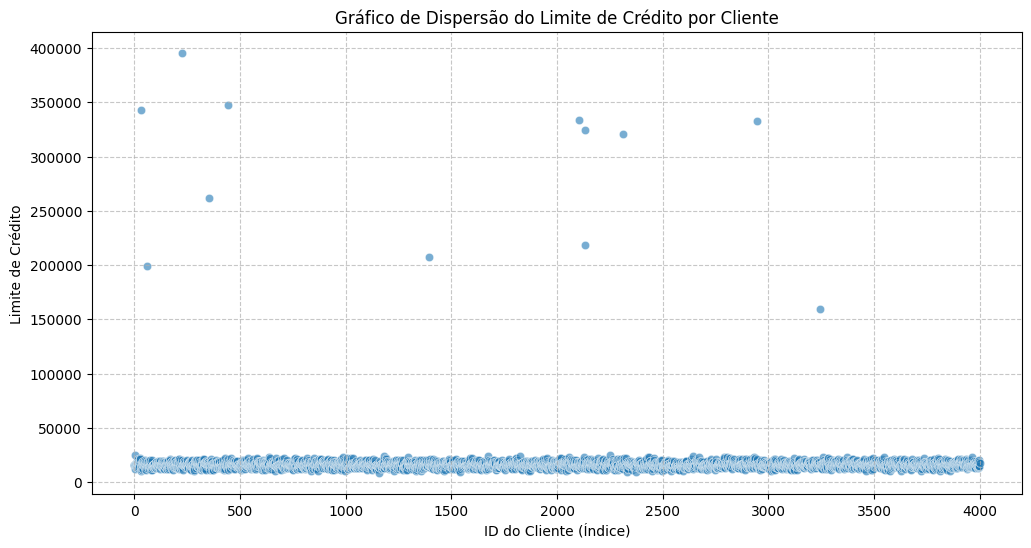

In [46]:
print('Estatísticas Descritivas para a coluna limite_credito:')
display(df_clientes['limite_credito'].describe())

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_clientes.index, y=df_clientes['limite_credito'], alpha=0.6)
plt.title('Gráfico de Dispersão do Limite de Crédito por Cliente')
plt.xlabel('ID do Cliente (Índice)')
plt.ylabel('Limite de Crédito')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Removendo Outliers da Coluna 'limite_credito' com o Método IQR

Agora que visualizamos os *outliers* no `limite_credito`, optei por removê-los usando o método do Intervalo Interquartil (IQR).

In [47]:
# Calcular Q1 (primeiro quartil) e Q3 (terceiro quartil)
Q1 = df_clientes['limite_credito'].quantile(0.25)
Q3 = df_clientes['limite_credito'].quantile(0.75)
IQR = Q3 - Q1

# Definir limites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Inferior para Outliers: {limite_inferior:.2f}")
print(f"Limite Superior para Outliers: {limite_superior:.2f}")

# Contar o número de outliers
outliers_limite_credito = df_clientes[(df_clientes['limite_credito'] < limite_inferior) | (df_clientes['limite_credito'] > limite_superior)]
num_outliers_removidos = len(outliers_limite_credito)

# Filtrar o DataFrame para remover os outliers
df_clientes_sem_outliers_limite = df_clientes[(df_clientes['limite_credito'] >= limite_inferior) & (df_clientes['limite_credito'] <= limite_superior)].copy()

print(f"\nNúmero de Outliers de 'limite_credito' removidos: {num_outliers_removidos}")
print(f"Número de registros após remoção de outliers: {len(df_clientes_sem_outliers_limite)}")

# Exibir estatísticas descritivas do limite de crédito após a remoção dos outliers
print("\nEstatísticas Descritivas para a coluna 'limite_credito' (após remoção de outliers):")
display(df_clientes_sem_outliers_limite['limite_credito'].describe())

# Comparar a média antes e depois da remoção
media_antes_outliers = df_clientes['limite_credito'].mean()
media_depois_outliers = df_clientes_sem_outliers_limite['limite_credito'].mean()
impacto_percentual_limite = ((media_antes_outliers - media_depois_outliers) / media_antes_outliers) * 100

print(f"Média do Limite de Crédito Antes da Remoção de Outliers: {media_antes_outliers:.2f}")
print(f"Média do Limite de Crédito Depois da Remoção de Outliers: {media_depois_outliers:.2f}")
print(f"Impacto na média do limite de crédito: {abs(impacto_percentual_limite):.2f}% de redução")

Q1: 14356.07
Q3: 17768.07
IQR: 3412.00
Limite Inferior para Outliers: 9238.07
Limite Superior para Outliers: 22886.07

Número de Outliers de 'limite_credito' removidos: 33
Número de registros após remoção de outliers: 3942

Estatísticas Descritivas para a coluna 'limite_credito' (após remoção de outliers):


,limite_credito
count,3942.000000
mean,16046.520452
std,2419.638210
min,9335.320000
25%,14345.892500
50%,15882.275000
75%,17710.177500
max,22835.990000


Média do Limite de Crédito Antes da Remoção de Outliers: 16896.19
Média do Limite de Crédito Depois da Remoção de Outliers: 16046.52
Impacto na média do limite de crédito: 5.03% de redução


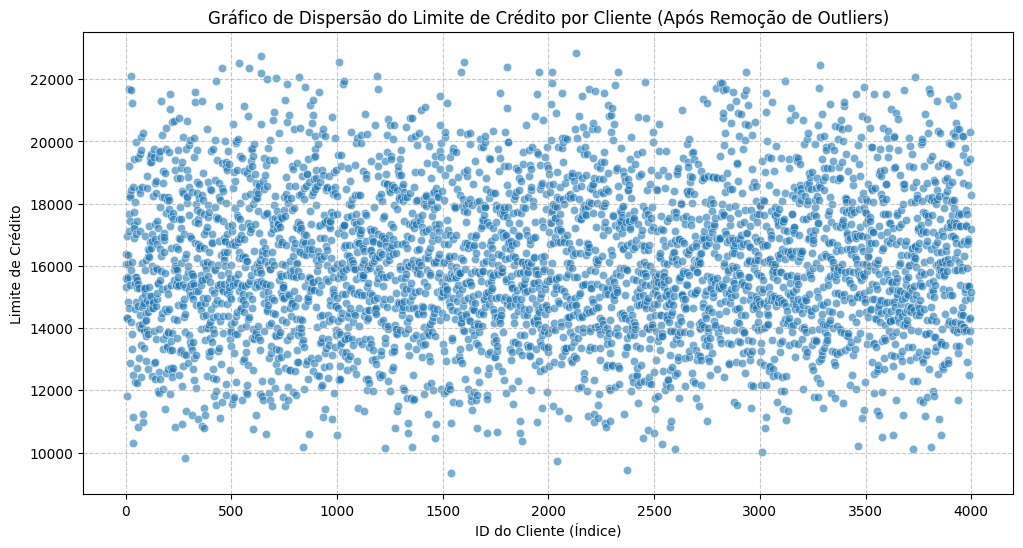

In [48]:
# Visualizar a distribuição do limite de crédito após a remoção dos outliers com um scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_clientes_sem_outliers_limite.index, y=df_clientes_sem_outliers_limite['limite_credito'], alpha=0.6)
plt.title('Gráfico de Dispersão do Limite de Crédito por Cliente (Após Remoção de Outliers)')
plt.xlabel('ID do Cliente (Índice)')
plt.ylabel('Limite de Crédito')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Partindo para a Estatística descritiva com os dados Limpos

### Estatísticas Descritivas Gerais da Base de Clientes (Dados Limpos)

Vamos analisar as principais métricas para `idade`, `score_credito` e `limite_credito` na base de clientes após a limpeza de *outliers*.

In [49]:
print("Estatísticas Descritivas para a Idade:")
display(df_clientes_sem_outliers_limite['idade'].describe())

print("\nEstatísticas Descritivas para o Limite de Crédito:")
display(df_clientes_sem_outliers_limite['limite_credito'].describe())

# Para score_credito, filtramos 'Nao_Informado' para calcular estatísticas numéricas
score_credito_numerico = df_clientes_sem_outliers_limite[df_clientes_sem_outliers_limite['score_credito'] != 'Nao_Informado']['score_credito'].astype(float)
print("\nEstatísticas Descritivas para o Score de Crédito (apenas valores informados):")
display(score_credito_numerico.describe())

print("\nContagem de Categorias para o Score de Crédito:")
display(df_clientes_sem_outliers_limite['score_credito'].value_counts())

Estatísticas Descritivas para a Idade:


,idade
count,3942.000000
mean,40.925165
std,11.855115
min,18.000000
25%,33.000000
50%,41.000000
75%,49.000000
max,85.000000



Estatísticas Descritivas para o Limite de Crédito:


,limite_credito
count,3942.000000
mean,16046.520452
std,2419.638210
min,9335.320000
25%,14345.892500
50%,15882.275000
75%,17710.177500
max,22835.990000



Estatísticas Descritivas para o Score de Crédito (apenas valores informados):


,score_credito
count,3763.000000
mean,639.134999
std,78.783179
min,425.000000
25%,579.000000
50%,632.000000
75%,693.000000
max,897.000000



Contagem de Categorias para o Score de Crédito:


,count
score_credito,
Nao_Informado,179
619.0,30
588.0,30
560.0,26
591.0,26
...,...
469.0,1
889.0,1
839.0,1


### Análise por Segmento de Cartão

Agora, vamos investigar se o perfil dos clientes (idade, score, limite de crédito) muda significativamente entre os diferentes segmentos de cartão (`Classic`, `Gold`, `Platinum`, `Black`).

Primeiramente, vamos obter as estatísticas descritivas para cada segmento.

Estatísticas Descritivas por Segmento de Cartão (Idade e Limite de Crédito):


idade                                                       \
                  count       mean        std   min    25%   50%   75%   max   
segmento_cartao                                                                
Black             261.0  41.042146  12.512230  18.0  33.00  41.0  50.0  77.0   
Classic          1728.0  41.093750  12.153544  18.0  32.75  41.0  49.0  85.0   
Gold             1099.0  40.519563  11.349006  18.0  33.00  40.0  48.0  78.0   
Platinum          675.0  40.973333  11.643284  18.0  33.00  41.0  49.0  73.0   

                limite_credito                ...                        \
                         count          mean  ...         75%       max   
segmento_cartao                               ...                         
Black                    261.0  19372.126705  ...  20594.0800  22835.99   
Classic                 1728.0  14569.245231  ...  15792.2375  22561.63   
Gold                    1099.0  16376.645833  ...  17688.5050  21952.64   
Platinum                 675.0  17974.701126  ...  19212.9000  22731.27   

                score_credito                                               \
                        count        mean        std    min     25%    50%   
segmento_cartao                                                              
Black                   261.0  779.517241  44.035701  678.0  750.00  778.0   
Classic                1728.0  579.023148  44.872638  425.0  547.75  578.0   
Gold                   1099.0  651.188353  44.479319  514.0  622.00  651.0   
Platinum                675.0  719.115556  44.436949  545.0  689.50  718.0   

                               
                   75%    max  
segmento_cartao                
Black            809.0  897.0  
Classic          610.0  720.0  
Gold             680.0  779.0  
Platinum         747.0  847.0  

[4 rows x 24 columns]

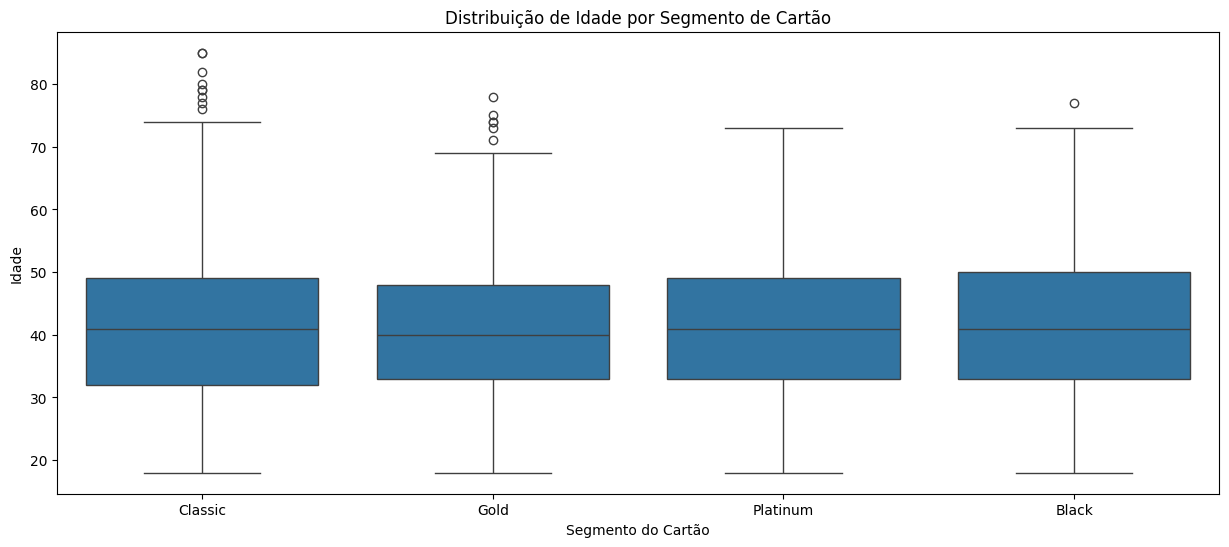

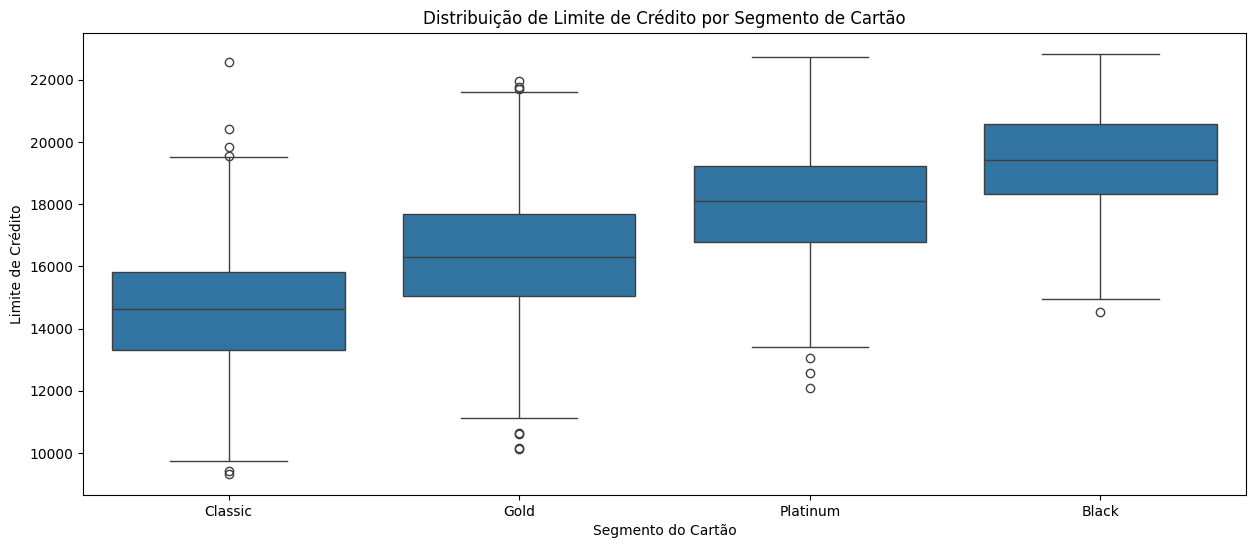

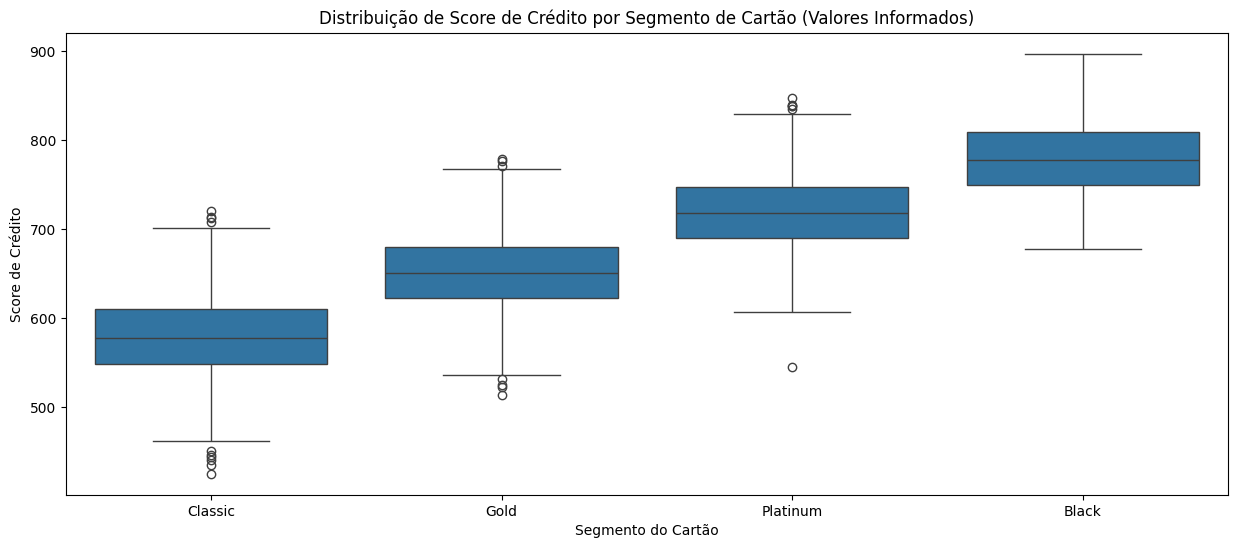

In [56]:
# Agrupar por segmento de cartão e calcular estatísticas descritivas para idade e limite_credito
print("Estatísticas Descritivas por Segmento de Cartão (Idade e Limite de Crédito):")

# Filtrar apenas scores numéricos para cálculo da média por segmento
df_segmento_numerico = df_clientes_sem_outliers_limite[df_clientes_sem_outliers_limite['score_credito'] != 'Nao_Informado'].copy()
df_segmento_numerico['score_credito'] = df_segmento_numerico['score_credito'].astype(float)

display(df_segmento_numerico.groupby('segmento_cartao')[['idade', 'limite_credito', 'score_credito']].describe())

# Visualização da distribuição de Idade por Segmento de Cartão
plt.figure(figsize=(15, 6))
sns.boxplot(x='segmento_cartao', y='idade', data=df_clientes_sem_outliers_limite)
plt.title('Distribuição de Idade por Segmento de Cartão')
plt.xlabel('Segmento do Cartão')
plt.ylabel('Idade')
plt.show()

# Visualização da distribuição de Limite de Crédito por Segmento de Cartão
plt.figure(figsize=(15, 6))
sns.boxplot(x='segmento_cartao', y='limite_credito', data=df_clientes_sem_outliers_limite)
plt.title('Distribuição de Limite de Crédito por Segmento de Cartão')
plt.xlabel('Segmento do Cartão')
plt.ylabel('Limite de Crédito')
plt.show()

# Visualização da distribuição de Score de Crédito por Segmento de Cartão (apenas valores numéricos)
plt.figure(figsize=(15, 6))
sns.boxplot(x='segmento_cartao', y='score_credito', data=df_segmento_numerico)
plt.title('Distribuição de Score de Crédito por Segmento de Cartão (Valores Informados)')
plt.xlabel('Segmento do Cartão')
plt.ylabel('Score de Crédito')
plt.show()



### Mapa de Calor das Correlações

Vamos agora visualizar as correlações entre as variáveis numéricas `idade`, `score_credito` e `limite_credito` utilizando um mapa de calor. Isso nos ajudará a identificar rapidamente a força e a direção dos relacionamentos lineares entre essas variáveis.

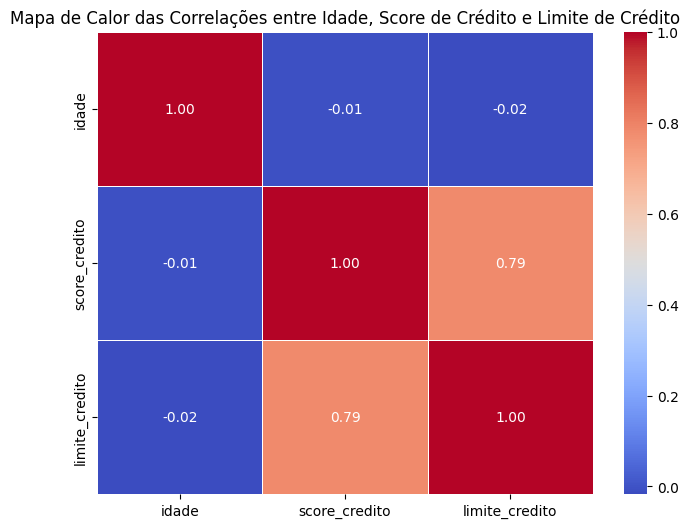

In [57]:
# Calcular a matriz de correlação
correlation_matrix = df_segmento_numerico[['idade', 'score_credito', 'limite_credito']].corr()

# Gerar o mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor das Correlações entre Idade, Score de Crédito e Limite de Crédito')
plt.show()

# Cruzando dados da Tabela Df_clientes e Df_transacoes
Cruzando estas duas tabelas afim de analisar mais profundamente o compartamento dos Clientes NeoCard, como por exemplo: volume de atividade transacional para cada combinação de segmento e região, total gasto pelos clientes em cada grupo, o valor médio que um cliente gasta por transação ou durante determinado período, dentre outras analises.

In [75]:
# Mesclar df_clientes_sem_outliers_limite com df_transacoes
df_merged = pd.merge(df_clientes_sem_outliers_limite, df_transacoes, on='id_cliente', how='inner')

# Calcular métricas agregadas por segmento e região
analise_segmento_regiao = df_merged.groupby(['segmento_cartao', 'regiao']).agg(
    numero_de_transacoes=('id_transacao', 'count'),
    gasto_total=('valor_transacao', 'sum'),
    gasto_medio_por_cliente=('valor_transacao', 'mean') # Gasto médio por transação neste contexto
).reset_index()

analise_segmento_regiao['gasto_medio_por_cliente'] = analise_segmento_regiao['gasto_medio_por_cliente'].round(2)

#
print("Análise Agregada por Segmento de Cartão e Região:")
display(analise_segmento_regiao.head(50))

Análise Agregada por Segmento de Cartão e Região:


,segmento_cartao,regiao,numero_de_transacoes,gasto_total,gasto_medio_por_cliente
0,Black,Centro-Oeste,3241,950270.94,296.68
1,Black,Nordeste,5926,1678853.31,286.30
2,Black,Norte,1658,458139.15,278.84
3,Black,Sudeste,12327,3413954.76,279.74
4,Black,Sul,6100,1797601.77,298.16
5,Classic,Centro-Oeste,6074,1653045.77,274.59
6,Classic,Nordeste,13401,3772686.75,284.45
7,Classic,Norte,3736,1071611.21,289.86
8,Classic,Sudeste,25787,7273823.57,285.07
9,Classic,Sul,13089,3718050.63,286.64


### Gasto Total por Região

Vamos visualizar o gasto total realizado pelos clientes em cada região para identificar quais regiões geram mais receita.

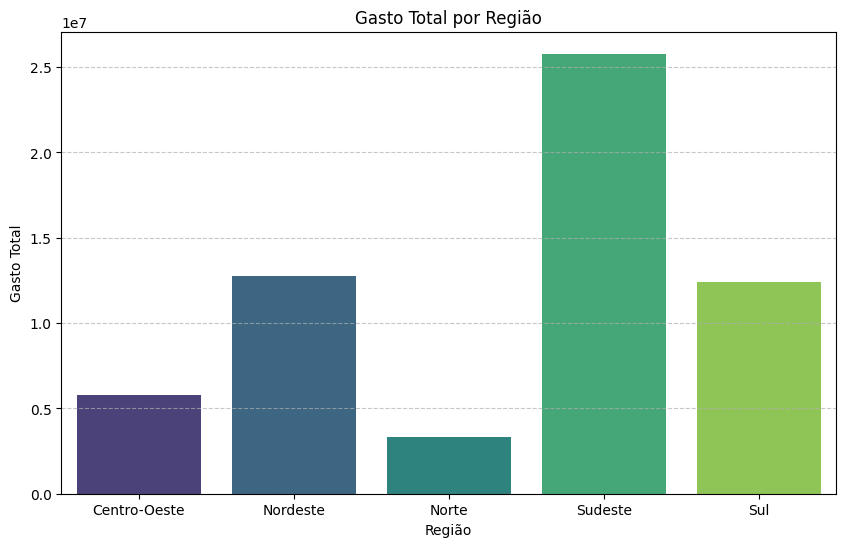

In [72]:
# Calcular o gasto total por região
gasto_total_por_regiao = analise_segmento_regiao.groupby('regiao')['gasto_total'].sum().reset_index()

# Gerar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='regiao', y='gasto_total', data=gasto_total_por_regiao, palette='viridis', hue='regiao', legend=False)
plt.title('Gasto Total por Região')
plt.xlabel('Região')
plt.ylabel('Gasto Total')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()